# B14 — The Visualization Suite

**Track B — the SDK.** Qiskit ships six or seven ways to draw a quantum state,
and no two of them show the same thing.

---

## The one-sentence version

`plot_bloch_multivector` draws one Bloch sphere per qubit. On an **entangled**
state both arrows shrink to zero length and the picture shows *nothing* — at
exactly the moment the state has become interesting. That is not a bug in the
plotting code. It is the honest answer to a question that was the wrong question.

This notebook is the tour: what each visualizer encodes, what it throws away, and
which one to reach for. Along the way we compare Qiskit's renderings against this
repo's own amplitude bars — and say plainly where Qiskit's are better.

## Where we are

A01 and A02 built the pictures from scratch: amplitude bars with phase as hue, and
a hand-rolled Bloch sphere fed by $\vec r = (\langle X\rangle, \langle
Y\rangle, \langle Z\rangle)$. B13 flashed all five Qiskit state visualizers past
in a single figure — the index card. Here we slow down and actually read them.

| Track A (by hand) | Qiskit |
|---|---|
| `grid.amp_bars` — height = $\lvert a_i\rvert$, hue = $\arg a_i$ | `plot_state_qsphere` |
| `grid.matrix(rho)` heatmap | `plot_state_city`, `plot_state_hinton` |
| expectation values printed as bars (A02) | `plot_state_paulivec` |
| `bloch.sphere` + `bloch.vector` | `plot_bloch_multivector`, `plot_bloch_vector` |
| `grid.prob_bars` | `plot_histogram`, `plot_distribution` |
| matplotlib by hand | `qc.draw("mpl", style=...)` |

**A quick note on the pinned version.** Everything here is Qiskit 2.5. Older
tutorials reach for `execute()`, `Aer.get_backend()`, `qiskit.opflow` and
Primitives V1 — all removed. The visualization module survived 2.0 essentially
intact, which is why this is one of the safer corners of the SDK to learn from
old material. The list of what did *not* survive is in `CLAUDE.md`.

In [1]:
from qviz import backends, bloch, grid, style

import warnings

import matplotlib.pyplot as plt
import numpy as np
import qiskit
from qiskit import QuantumCircuit
from qiskit.circuit import ClassicalRegister, QuantumRegister
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import (DensityMatrix, Pauli, Statevector, entropy,
                                 partial_trace)
from qiskit.visualization import (plot_bloch_multivector, plot_bloch_vector,
                                  plot_histogram, plot_state_city,
                                  plot_state_hinton, plot_state_paulivec,
                                  plot_state_qsphere)

style.use()

# Every qiskit.visualization function ends with fig.tight_layout(), and
# plot_state_qsphere builds its own GridSpec. This repo's style sets constrained
# layout, so the two layout engines argue about it out loud on every figure.
# Composite figures below switch the engine off where it matters; these two
# filters silence the leftover chatter so the outputs stay readable.
warnings.filterwarnings("ignore", message=".*[Tt]ight.*")
warnings.filterwarnings("ignore", message=".*gridspecs with layoutgrids.*")

SEED = backends.seed_for("B14")
rng = np.random.default_rng(SEED)
print("qiskit", qiskit.__version__, " seed", SEED)

qiskit 2.5.1  seed 20260818


## Two states, one gate apart

Everything in this notebook is a comparison between these two circuits. They
differ by a single `cx`.

**The product state** $|\psi_\otimes\rangle$: each qubit is put somewhere
interesting on its own sphere and then left alone. `t` is the $\pi/4$ phase gate
and `sdg` is $S^\dagger$, so neither qubit sits on an axis and neither has a real
amplitude — that matters, because half these visualizers can only show phase if
there is some phase to show.

**The Bell state** $|\Phi^+\rangle = (|00\rangle + |11\rangle)/\sqrt2$: the same
`h`, plus one `cx`.

Both are pure two-qubit states. Every visualizer below is handed both.

In [2]:
qc_prod = QuantumCircuit(2)
qc_prod.h(0)
qc_prod.t(0)        # qubit 0 -> (|0> + e^{i pi/4}|1>)/sqrt(2)
qc_prod.h(1)
qc_prod.sdg(1)      # qubit 1 -> (|0> - i|1>)/sqrt(2)

qc_bell = QuantumCircuit(2)
qc_bell.h(0)
qc_bell.cx(0, 1)

sv_prod = Statevector(qc_prod)
sv_bell = Statevector(qc_bell)

print("product state (h,t on q0; h,sdg on q1):")
print(grid.show_state(sv_prod.data))
print("\nBell state (h, cx):")
print(grid.show_state(sv_bell.data))

# A product state is exactly one that factorises. The definition is one line:
# tensor the two single-qubit states back together and compare.
psi0 = np.array([1, np.exp(1j * np.pi / 4)]) / np.sqrt(2)     # qubit 0
psi1 = np.array([1, -1j]) / np.sqrt(2)                        # qubit 1
# Little-endian: qubit 0 is the RIGHTMOST bit, so it is the RIGHT kron factor.
print("\nfactorises as psi1 (x) psi0 :",
      np.allclose(np.kron(psi1, psi0), sv_prod.data))

product state (h,t on q0; h,sdg on q1):
  |00>  +0.5000+0.0000j
  |01>  +0.3536+0.3536j
  |10>  +0.0000-0.5000j
  |11>  +0.3536-0.3536j

Bell state (h, cx):
  |00>  +0.7071+0.0000j
  |11>  +0.7071+0.0000j

factorises as psi1 (x) psi0 : True


## The contact sheet: five renderings of one state

Handed a `Statevector`, four of the five visualizers below immediately convert it
to a **density matrix** $\rho = |\psi\rangle\langle\psi|$ and draw *that* — a
$4\times4$ complex grid rather than a 4-vector. So the axes you are reading are
labelled by pairs of basis states, not single ones.

- **`plot_state_qsphere`** — every basis state as a node on one sphere. Latitude
  is Hamming weight (how many 1s), node **size** is probability, node **colour**
  is phase. The only Qiskit state plot that shows phase directly, and the closest
  relative of this repo's amplitude bars.
- **`plot_state_city`** — $\mathrm{Re}\,\rho$ and $\mathrm{Im}\,\rho$ as two
  fields of 3-D towers. Good for a first look at structure; genuinely bad for
  reading values, because towers occlude each other and 3-D perspective is not a
  quantitative channel.
- **`plot_state_hinton`** — the same two matrices with **area** encoding
  magnitude. Far easier to compare cell to cell than the city plot, and the right
  choice for watching off-diagonal terms die under noise (B26 leans on it).
- **`plot_state_paulivec`** — $\rho$ expanded in the Pauli basis,
  $\rho = \tfrac14\sum_{P} \langle P\rangle\, P$. This is the natural view when
  you care about expectation values — which is exactly what an `EstimatorV2`
  returns, so it is the view that matches what hardware can actually give you.
- **`plot_bloch_multivector`** — one sphere per qubit. Discussed at length below.

Most of them accept an `ax=` (or `ax_real=`/`ax_imag=`) argument, which is what
lets four of them be composed into one figure below.

**`plot_state_qsphere` is the exception, and it is worth knowing about.** It takes
an `ax=` but only to find the *figure*: internally it lays down its own
`GridSpec(3, 3)` and adds a new axis spanning the whole thing, plus a second one
for the phase-wheel legend. Pass it an axis inside your own subplot grid and it
will happily paint over everything else in the figure. So the qsphere gets a
figure to itself here, and so should yours.

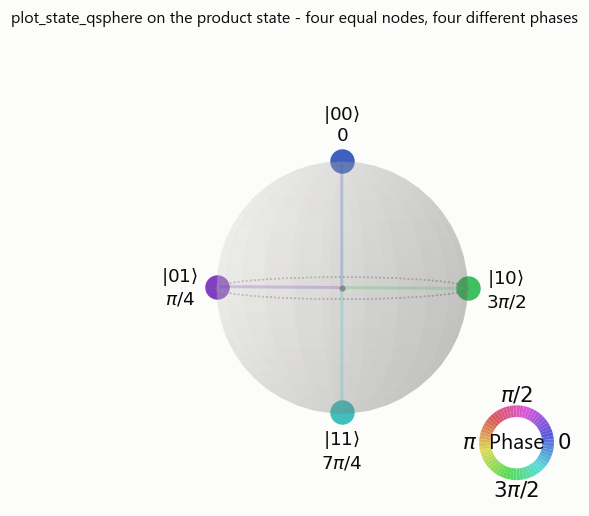

In [3]:
# qsphere insists on owning its figure -- see the note above.
f = plot_state_qsphere(sv_prod, figsize=(6.0, 5.0), show_state_phases=True)
f.suptitle("plot_state_qsphere on the product state - four equal nodes, "
           "four different phases",
           x=0.02, y=1.01, ha="left", fontsize=10.5, color=style.INK)
display(f)
plt.close(f)

Four nodes of equal size (all four basis states are equally likely) at four
different hues and four printed phase labels. That is the entire state in one
picture, and it is the picture that survives best as the qubit count grows.

Now the other four, composed — with this repo's amplitude bars in the sixth panel
for scale.

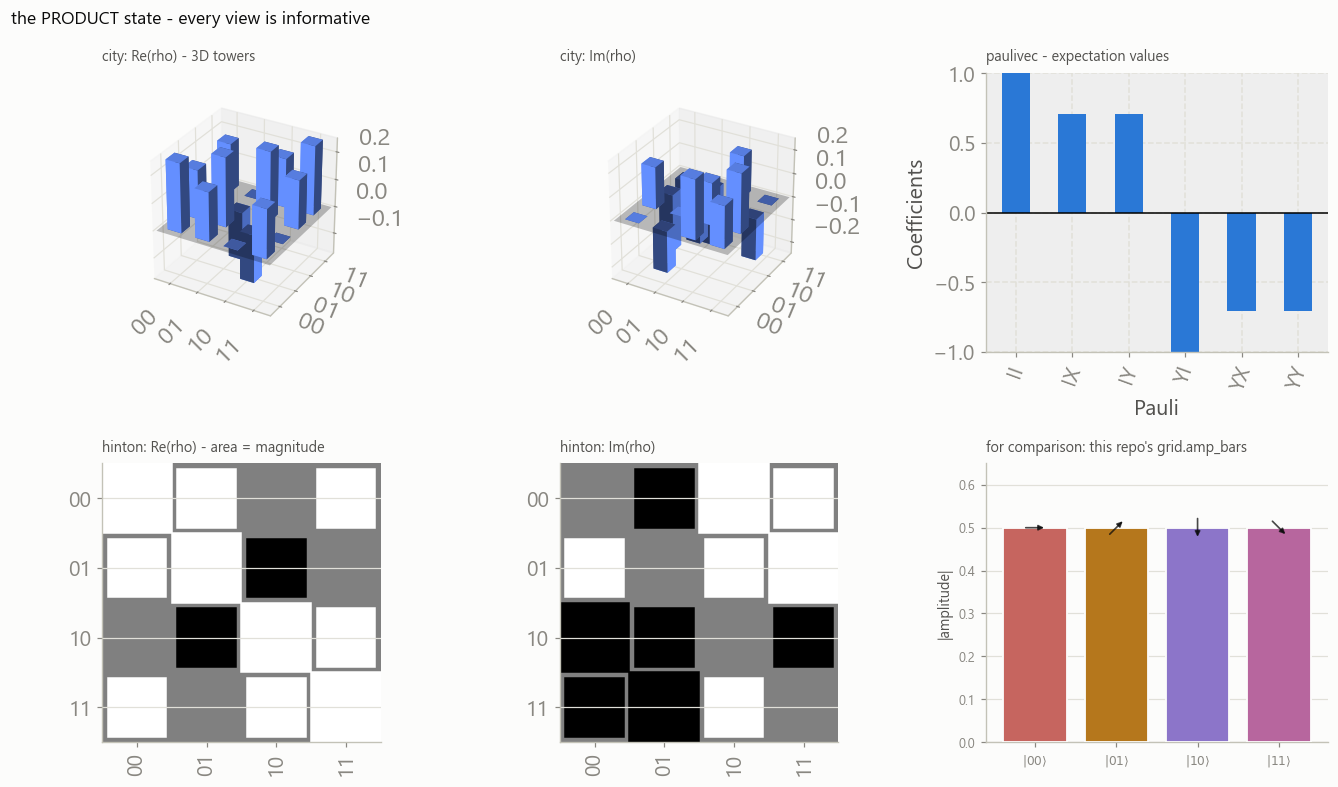

In [4]:
def contact_sheet(sv, name):
    """The three density-matrix views of one state, plus ours, in one figure."""
    fig = plt.figure(figsize=(12.6, 7.6))
    # Qiskit's plotters all call fig.tight_layout(), which fights the repo's
    # constrained layout and loses (panels overflow the right edge). Turn the
    # engine off and place the panels explicitly.
    fig.set_layout_engine("none")
    ax_cr = fig.add_subplot(2, 3, 1, projection="3d")
    ax_ci = fig.add_subplot(2, 3, 2, projection="3d")
    ax_pv = fig.add_subplot(2, 3, 3)
    ax_hr = fig.add_subplot(2, 3, 4)
    ax_hi = fig.add_subplot(2, 3, 5)
    ax_ab = fig.add_subplot(2, 3, 6)

    plot_state_city(sv, ax_real=ax_cr, ax_imag=ax_ci)
    plot_state_hinton(sv, ax_real=ax_hr, ax_imag=ax_hi)
    plot_state_paulivec(sv, ax=ax_pv, color=style.BLUE)
    grid.amp_bars(ax_ab, sv.data)

    for ax, cap in [(ax_cr, "city: Re(rho) - 3D towers"),
                    (ax_ci, "city: Im(rho)"),
                    (ax_pv, "paulivec - expectation values"),
                    (ax_hr, "hinton: Re(rho) - area = magnitude"),
                    (ax_hi, "hinton: Im(rho)"),
                    (ax_ab, "for comparison: this repo's grid.amp_bars")]:
        # matplotlib keeps three title artists per axis (left / centre / right).
        # Qiskit writes the centred one, so clear it or the two overprint.
        ax.set_title("", loc="center")
        ax.set_title(cap, loc="left", fontsize=9.5, color=style.INK_2, pad=8)
    fig.suptitle(name, x=0.012, y=0.975, ha="left", fontsize=11.5,
                 color=style.INK)
    fig.subplots_adjust(left=0.055, right=0.962, top=0.90, bottom=0.10,
                        wspace=0.34, hspace=0.40)
    return fig


fig = contact_sheet(sv_prod, "the PRODUCT state - every view is informative")
plt.show()

The city and hinton panels show the same $\rho$ twice. Note how much easier it is
to see in the *hinton* panel that every entry has the same magnitude — sixteen
equal squares — while the city plot makes you compare tower heights across a
perspective transform, with the front row occluding the back. Area beats 3-D
height for quantitative reading, every time.

The paulivec panel looks least like the others and is the most practically useful.
It describes the state entirely in terms of things you could measure, and every
bar in it is one basis change away from being a number on real hardware. Note that
it silently drops the Pauli terms that are zero — six bars, not sixteen.

The bottom-right panel is this repo's `amp_bars` on the same state: four equal
heights, four different hues, four clock hands. It is the only panel in the figure
from which you can read both the magnitude *and* the phase of a specific
amplitude directly.

### And the fifth: one sphere per qubit

For a product state this is the *best* of the five. Two qubits, two arrows, each
of unit length, each pointing where you put it. Nothing is lost, because for a
product state there genuinely is nothing beyond the two individual qubits.

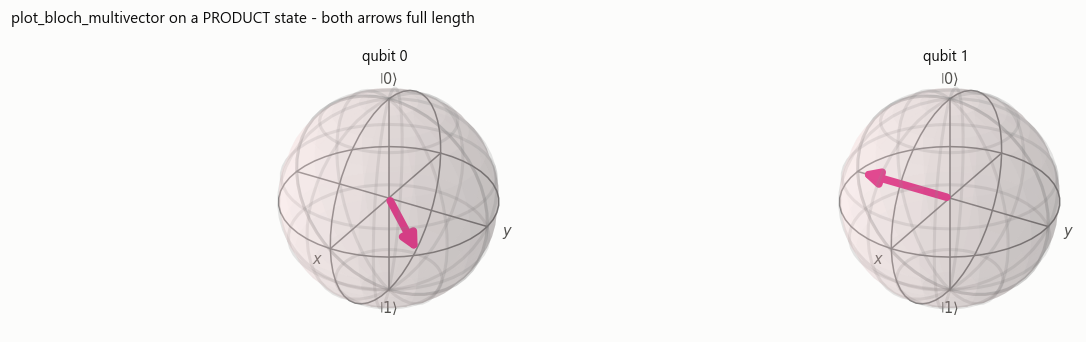

In [5]:
f = plot_bloch_multivector(sv_prod, figsize=(6.2, 3.0))
f.suptitle("plot_bloch_multivector on a PRODUCT state - both arrows full length",
           x=0.02, y=1.02, ha="left", fontsize=10, color=style.INK)
display(f)
plt.close(f)

## The centrepiece: the same plot, one `cx` later

Now the Bell state. Same function, one extra gate in the circuit. Below, all four
spheres in one figure: the product state's two qubits on the left, the Bell
state's two on the right.

The Bloch vectors are computed here rather than left to Qiskit, so that nothing is
hidden: take the partial trace to get each qubit's reduced density matrix, then
read off $\vec r = (\mathrm{Tr}\,\rho X,\ \mathrm{Tr}\,\rho Y,\ \mathrm{Tr}\,\rho
Z)$ — the A02 recipe, unchanged. Those three numbers are precisely what
`plot_bloch_multivector` computes internally, so drawing them with
`plot_bloch_vector` is the same picture with the machinery exposed.

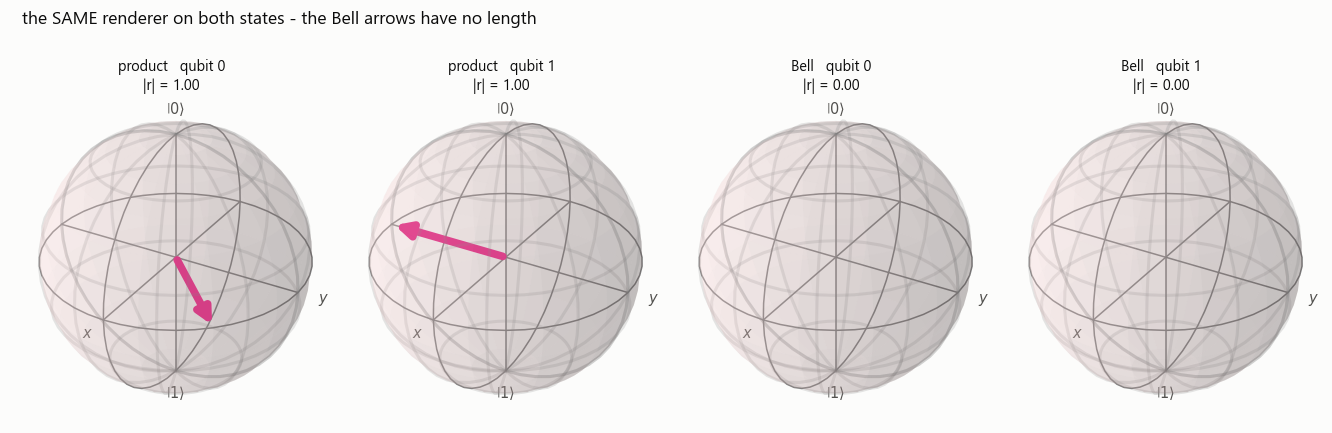

In [6]:
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
PAULIS = (X, Y, Z)


def reduced(sv, keep):
    """rho of qubit `keep`, with the other one traced out."""
    other = [q for q in range(sv.num_qubits) if q != keep]
    return partial_trace(sv, other).data


def bloch_of(rho):
    """r = (Tr rho X, Tr rho Y, Tr rho Z) -- A02's map, for a mixed state."""
    return np.array([float(np.real(np.trace(rho @ P))) for P in PAULIS])


panels = [("product", sv_prod, 0), ("product", sv_prod, 1),
          ("Bell", sv_bell, 0), ("Bell", sv_bell, 1)]

fig = plt.figure(figsize=(12.0, 3.8))
for i, (name, sv, q) in enumerate(panels):
    ax = fig.add_subplot(1, 4, i + 1, projection="3d")
    r = bloch_of(reduced(sv, q))
    plot_bloch_vector(list(r), ax=ax,
                      title=f"{name}   qubit {q}\n|r| = {np.linalg.norm(r):.2f}")
fig.suptitle("the SAME renderer on both states - the Bell arrows have no length",
             x=0.012, y=1.10, ha="left", fontsize=11.5, color=style.INK)
plt.show()

In [7]:
for name, sv in [("product", sv_prod), ("Bell", sv_bell)]:
    print(f"--- {name} state")
    for q in (0, 1):
        rho = reduced(sv, q)
        r = bloch_of(rho)
        print(f"  qubit {q}:  rho = {np.round(rho, 3).tolist()}")
        print(f"            r = {np.round(r, 4)}   |r| = {np.linalg.norm(r):.4f}"
              f"   purity Tr(rho^2) = {float(np.real(np.trace(rho @ rho))):.4f}")
    rho_full = DensityMatrix(sv).data
    print(f"  the PAIR:  purity = "
          f"{float(np.real(np.trace(rho_full @ rho_full))):.4f}"
          "   (1.0 -> the pair is pure either way)")

--- product state
  qubit 0:  rho = [[(0.5+0j), (0.354-0.354j)], [(0.354+0.354j), (0.5+0j)]]
            r = [0.7071 0.7071 0.    ]   |r| = 1.0000   purity Tr(rho^2) = 1.0000
  qubit 1:  rho = [[(0.5+0j), 0.5j], [-0.5j, (0.5+0j)]]
            r = [ 0. -1.  0.]   |r| = 1.0000   purity Tr(rho^2) = 1.0000
  the PAIR:  purity = 1.0000   (1.0 -> the pair is pure either way)
--- Bell state
  qubit 0:  rho = [[(0.5+0j), 0j], [0j, (0.5+0j)]]
            r = [0. 0. 0.]   |r| = 0.0000   purity Tr(rho^2) = 0.5000
  qubit 1:  rho = [[(0.5+0j), 0j], [0j, (0.5+0j)]]
            r = [0. 0. 0.]   |r| = 0.0000   purity Tr(rho^2) = 0.5000
  the PAIR:  purity = 1.0000   (1.0 -> the pair is pure either way)


And to be sure this is Qiskit's own behaviour and not something introduced by
recomputing the vectors by hand — here is the actual library function on the
actual Bell state. Two spheres, no arrows at all, and the caption is the only
thing on the page carrying information.

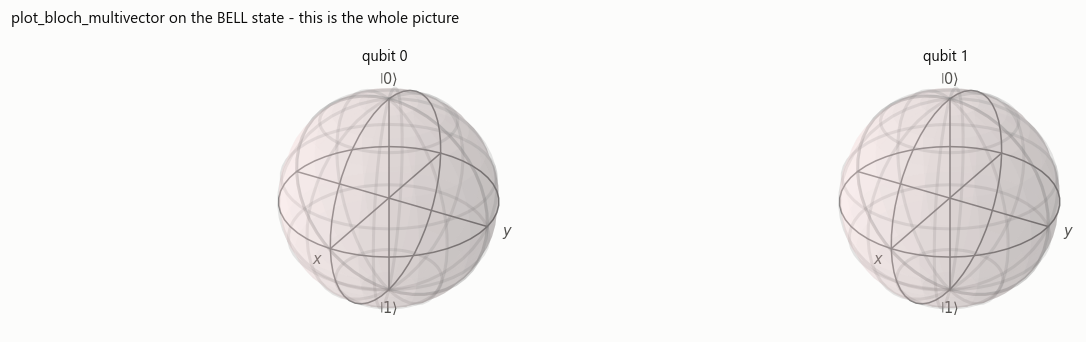

In [8]:
f = plot_bloch_multivector(sv_bell, figsize=(6.2, 3.0))
f.suptitle("plot_bloch_multivector on the BELL state - this is the whole picture",
           x=0.02, y=1.02, ha="left", fontsize=10, color=style.INK)
display(f)
plt.close(f)

## Why the arrows vanish

Not a rendering failure. The arrows are the correct length, and the correct length
is zero.

`plot_bloch_multivector` cannot plot "qubit 0" as a state, because in an entangled
state **qubit 0 does not have a state of its own**. The best anyone can do is the
*reduced* density matrix — what qubit 0 looks like to someone who will never see
qubit 1:

$$\rho_0 \;=\; \mathrm{Tr}_1\,|\Phi^+\rangle\langle\Phi^+| \;=\;
\tfrac12\begin{pmatrix}1&0\\0&1\end{pmatrix} \;=\; \tfrac{I}{2}.$$

That is the **maximally mixed** qubit: every measurement on it, in every basis, is
a fair coin. Feed it through A02's map and every expectation value is zero,

$$\mathrm{Tr}\!\left(\tfrac{I}{2}X\right) =
\mathrm{Tr}\!\left(\tfrac{I}{2}Y\right) =
\mathrm{Tr}\!\left(\tfrac{I}{2}Z\right) = 0
\quad\Longrightarrow\quad \vec r = \vec 0,$$

so the arrow has length 0 and sits at the centre of the ball. Both qubits give the
same answer. A picture made of two arrows has *nowhere to put* the one thing that
distinguishes $|\Phi^+\rangle$ from a pair of coin flips, because that thing is
not a property of either qubit — it is a property of the **pair**.

The purity numbers above make it sharp. Each qubit alone has
$\mathrm{Tr}\,\rho_q^2 = 0.5$, the minimum possible for one qubit: total
ignorance. The pair has $\mathrm{Tr}\,\rho^2 = 1.0$: perfect knowledge. Knowing
everything about a whole while knowing nothing about either part has no classical
analogue at all, and it is the entire content of entanglement.

**The rule of thumb.** A zero-length arrow in `plot_bloch_multivector` is not a
bug report, it is a *flag*: this qubit is entangled with something. A short arrow
means partly entangled — or noisy, and the picture cannot tell those apart
either.

## What to draw instead

Two of the five survive the switch intact, because neither ever claimed to be
per-qubit.

- **qsphere** still shows exactly two nodes, $|00\rangle$ and $|11\rangle$, both
  at half probability, both at phase 0 — which *is* the Bell state, correctly and
  completely.
- **paulivec** still shows the three bars that matter: $\langle XX\rangle = +1$,
  $\langle YY\rangle = -1$, $\langle ZZ\rangle = +1$. Every single-qubit term is
  exactly zero — and since the plot omits zero coefficients entirely, the Bell
  panel below has *no* single-qubit bars at all. Their absence is the vanished
  Bloch arrows; the two-qubit bars that remain are what the arrows could not hold.

Compare that with the product state's panel, where the bars are `IX`, `IY`, `YI`,
`YX`, `YY` — one-qubit terms and two-qubit terms together, and the two-qubit ones
are just products of the one-qubit ones. Below: the Bell state's qsphere, then
paulivec on both states side by side.

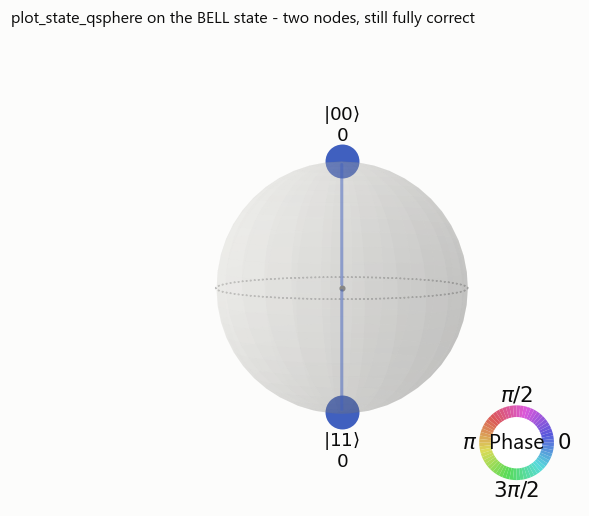

In [9]:
f = plot_state_qsphere(sv_bell, figsize=(6.0, 5.0), show_state_phases=True)
f.suptitle("plot_state_qsphere on the BELL state - two nodes, still fully correct",
           x=0.02, y=1.01, ha="left", fontsize=10.5, color=style.INK)
display(f)
plt.close(f)

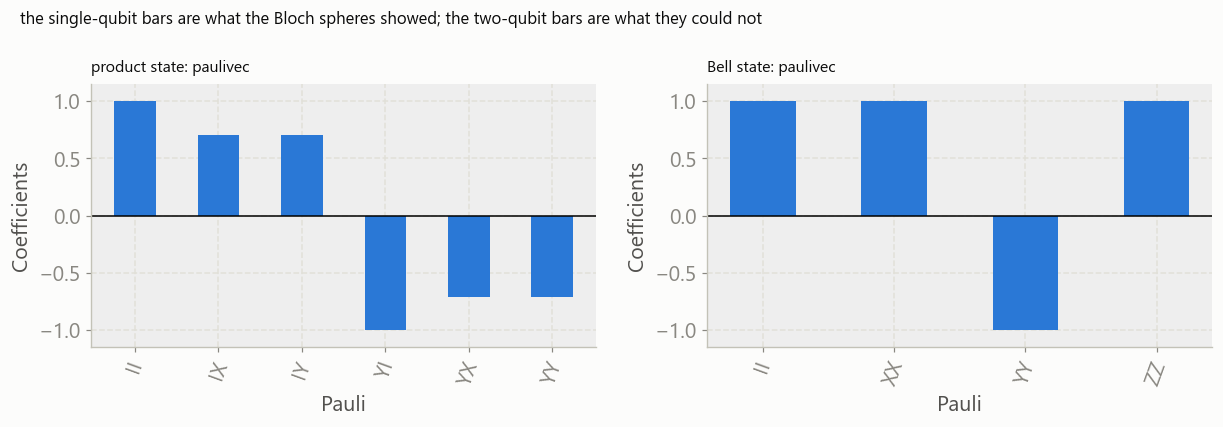

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 3.8))
fig.set_layout_engine("none")
for ax, (name, sv) in zip(axes, [("product", sv_prod), ("Bell", sv_bell)]):
    plot_state_paulivec(sv, ax=ax, color=style.BLUE)
    ax.set_ylim(-1.15, 1.15)
    ax.set_title(f"{name} state: paulivec", loc="left", fontsize=10.5,
                 color=style.INK, pad=8)
fig.suptitle("the single-qubit bars are what the Bloch spheres showed; "
             "the two-qubit bars are what they could not",
             x=0.012, y=0.975, ha="left", fontsize=11, color=style.INK)
fig.subplots_adjust(left=0.07, right=0.98, top=0.80, bottom=0.17, wspace=0.22)
plt.show()

### The honest picture: a correlation table

If the story is "the information is in the correlations", then draw the
correlations. Every two-qubit state is fully described by the sixteen numbers

$$M_{jk} \;=\; \big\langle\, P_j^{(0)} \otimes P_k^{(1)} \big\rangle,
\qquad P \in \{I, X, Y, Z\},$$

and each of them is directly measurable. The top row and left column are the
single-qubit Bloch vectors — the exact content of `plot_bloch_multivector`. The
$3\times3$ block in the corner is everything that plot throws away.

**One endianness trap on the way.** A Qiskit `Pauli` label is written
**highest-qubit-first**: `Pauli("XZ")` means $X$ on qubit **1** and $Z$ on qubit
**0**, the same right-to-left convention as a bitstring (CLAUDE.md §3). So to put
`row` on qubit 0 and `col` on qubit 1 the label is `col + row`, which looks
backwards and is not.

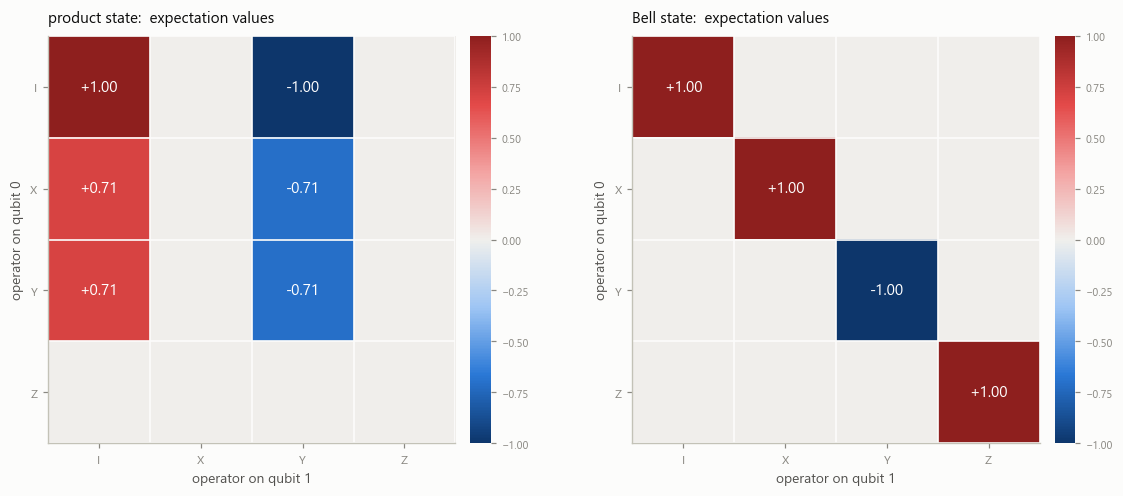

product: top row  (= qubit 1's Bloch vector) : [ 0. -1.  0.]
         left col (= qubit 0's Bloch vector) : [0.7071 0.7071 0.    ]
         the 3x3 corner block IS the outer product of those two: True

Bell:    top row : [0. 0. 0.]    left col : [0. 0. 0.]
         <XX>, <YY>, <ZZ> = [ 1. -1.  1.]


In [11]:
PLABELS = ["I", "X", "Y", "Z"]


def correlation_table(sv):
    """M[j, k] = <P_j on qubit 0  (x)  P_k on qubit 1>."""
    M = np.zeros((4, 4))
    for j, row in enumerate(PLABELS):          # row -> qubit 0
        for k, col in enumerate(PLABELS):      # col -> qubit 1
            # label is qubit1 + qubit0: little-endian, like a bitstring.
            M[j, k] = float(np.real(sv.expectation_value(Pauli(col + row))))
    return M


M_prod, M_bell = correlation_table(sv_prod), correlation_table(sv_bell)

fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.4))
for ax, M, name in [(axes[0], M_prod, "product"), (axes[1], M_bell, "Bell")]:
    grid.matrix(ax, M, part="re", labels=PLABELS, vmax=1.0, annot=True,
                annot_size=10.0, fmt="{:+.2f}",
                title=f"{name} state:  expectation values")
    ax.set_xlabel("operator on qubit 1", fontsize=9)
    ax.set_ylabel("operator on qubit 0", fontsize=9)
plt.show()

r0_p, r1_p = bloch_of(reduced(sv_prod, 0)), bloch_of(reduced(sv_prod, 1))
print("product: top row  (= qubit 1's Bloch vector) :", np.round(M_prod[0, 1:], 4))
print("         left col (= qubit 0's Bloch vector) :", np.round(M_prod[1:, 0], 4))
print("         the 3x3 corner block IS the outer product of those two:",
      np.allclose(M_prod[1:, 1:], np.outer(r0_p, r1_p)))
print("\nBell:    top row :", np.round(M_bell[0, 1:], 4),
      "   left col :", np.round(M_bell[1:, 0], 4))
print("         <XX>, <YY>, <ZZ> =", np.round(np.diag(M_bell[1:, 1:]), 4))

Two pictures, and the difference is total.

**Product state.** The edges are full of signal and the corner block carries *no
new information*: it is exactly the outer product $\vec r_0\, \vec r_1^{\top}$ of
the two single-qubit Bloch vectors, verified above. The correlations are entirely
predicted by the parts, which is what "not entangled" means. Two Bloch spheres
really do tell you everything.

**Bell state.** The edges are all zero — that is the two blank spheres, drawn as
numbers. And the corner block is not zero at all: $\langle XX\rangle = +1$,
$\langle YY\rangle = -1$, $\langle ZZ\rangle = +1$. Perfect correlation in three
different bases at once, with no marginal information anywhere. No outer product
$\vec r_0\vec r_1^\top$ of *any* two vectors can have zeros along its edges and
$\pm1$ down its diagonal, which is a two-line proof that this state does not
factorise.

That corner block is also where the CHSH inequality lives. B19 takes four numbers
out of it, adds them up, and gets $2\sqrt2 > 2$.

### It is a dial, not a switch

Between "product" and "Bell" there is a continuum. Take

$$|\psi(t)\rangle = \cos t\,|00\rangle + \sin t\,|11\rangle,$$

a product state at $t = 0$ ($|00\rangle$) and at $t = \pi/2$ ($|11\rangle$), and
maximally entangled halfway between at $t = \pi/4$. The reduced state is
$\rho_0 = \mathrm{diag}(\cos^2 t, \sin^2 t)$, so

$$\vec r_0 = (0,\, 0,\, \cos 2t), \qquad \lVert \vec r_0 \rVert = |\cos 2t|.$$

Watch the arrow retract into the ball as the entanglement comes up, and come back
out the other side. This is the fade-out that `plot_bloch_multivector` performs
continuously, and it is the notebook's claim in one figure: **the arrow is
shortest exactly where the state is most interesting.** B18 turns this into a
proper entanglement dial with concurrence and Schmidt rank.

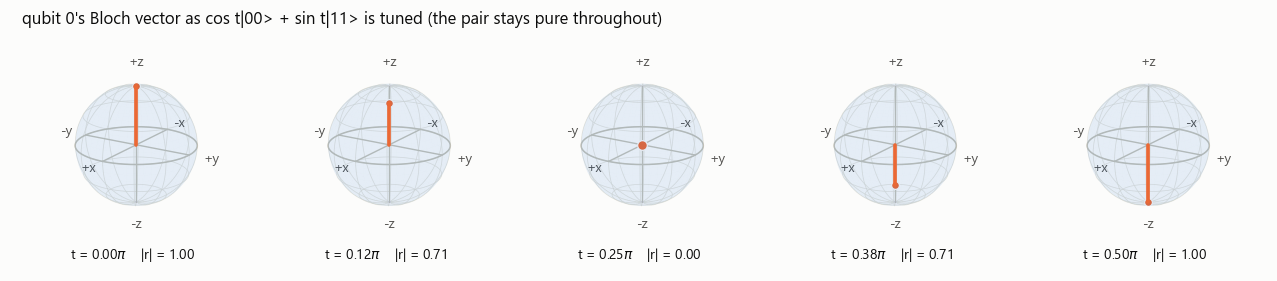

In [12]:
ts = np.linspace(0, np.pi / 2, 5)

fig, axes = grid.frames(len(ts), ncols=len(ts), panel=(2.3, 2.5),
                        projection="3d")
for ax, t in zip(axes, ts):
    sv_t = Statevector(np.array([np.cos(t), 0, 0, np.sin(t)], dtype=complex))
    r = bloch_of(reduced(sv_t, 0))
    bloch.sphere(ax, labels=True, label_kets=False, zoom=1.28)
    bloch.vector(ax, r, color=style.ORANGE)
    bloch.label(ax, f"t = {t / np.pi:.2f}" + r"$\pi$" +
                f"    |r| = {np.linalg.norm(r):.2f}", y=0.10, size=9.0)
fig.suptitle("qubit 0's Bloch vector as cos t|00> + sin t|11> is tuned "
             "(the pair stays pure throughout)",
             x=0.012, y=1.0, ha="left", fontsize=11, color=style.INK)
plt.show()

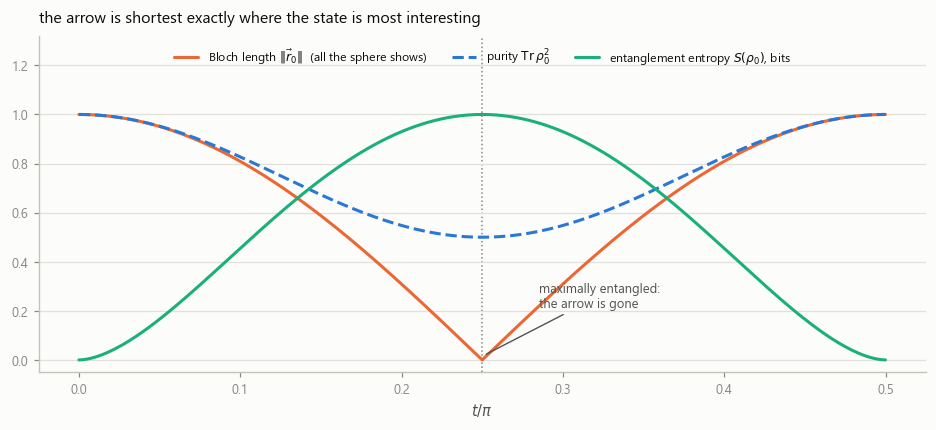

analytic check   |r| == |cos 2t| : True


In [13]:
ts_fine = np.linspace(0, np.pi / 2, 241)
rows = []
for t in ts_fine:
    sv_t = Statevector(np.array([np.cos(t), 0, 0, np.sin(t)], dtype=complex))
    rho0 = partial_trace(sv_t, [1])
    rows.append((np.linalg.norm(bloch_of(rho0.data)),
                 float(np.real(rho0.purity())),
                 float(entropy(rho0, base=2))))
r_len, purity, ent = np.array(rows).T

fig, ax = plt.subplots(figsize=(8.4, 3.8))
ax.plot(ts_fine / np.pi, r_len, color=style.ORANGE,
        label=r"Bloch length $\|\vec r_0\|$  (all the sphere shows)")
ax.plot(ts_fine / np.pi, purity, color=style.BLUE, ls="--",
        label=r"purity $\mathrm{Tr}\,\rho_0^2$")
ax.plot(ts_fine / np.pi, ent, color=style.AQUA,
        label=r"entanglement entropy $S(\rho_0)$, bits")
ax.axvline(0.25, color=style.MUTED, lw=1.0, ls=":", zorder=0)
grid.annotate(ax, "maximally entangled:\nthe arrow is gone",
              xy=(0.25, 0.015), xytext=(0.285, 0.26))
ax.set_xlabel(r"$t/\pi$")
ax.set_ylim(-0.05, 1.32)
ax.legend(loc="upper center", ncol=3, fontsize=8)
ax.set_title("the arrow is shortest exactly where the state is most interesting",
             loc="left", fontsize=10.5)
plt.show()

print("analytic check   |r| == |cos 2t| :",
      np.allclose(r_len, np.abs(np.cos(2 * ts_fine))))

## Drawing the circuit itself

`qc.draw()` has four renderers — `"text"`, `"mpl"`, `"latex"` and
`"latex_source"` — and the mpl one ships several named styles. They are not
purely cosmetic: `"clifford"` colours Clifford gates differently from
non-Clifford ones, which is a real distinction (Clifford circuits are classically
simulable in polynomial time — C30's subject), and `"bw"` is what to use when the
figure is going into print or a colour-unsafe context.

`"text"` is worth knowing precisely because it needs no matplotlib at all: it is
what to reach for in a terminal, a log file, or an assertion message.

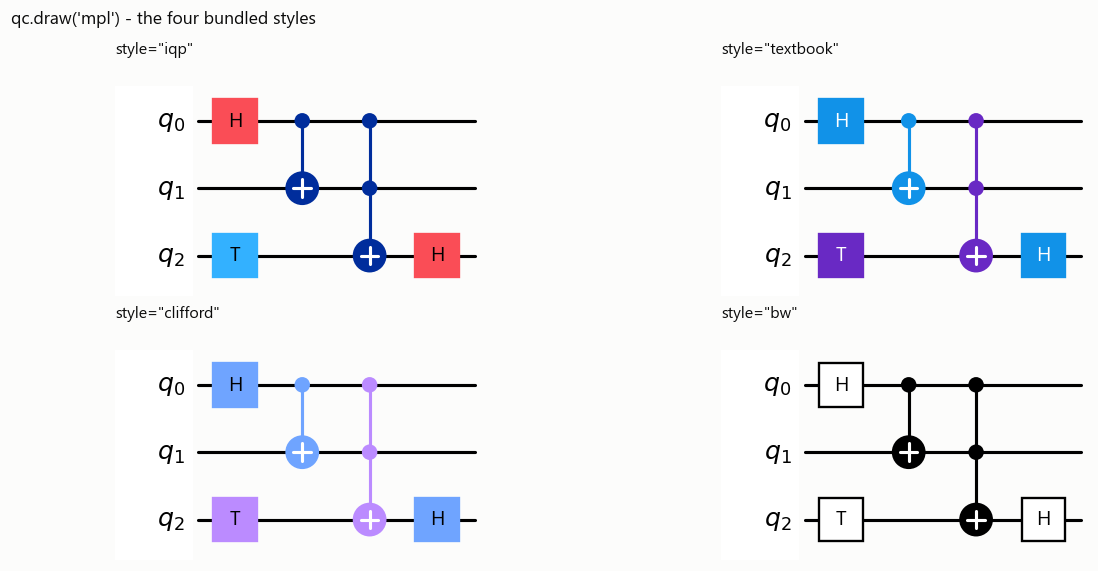

     ┌───┐               
q_0: ┤ H ├──■────■───────
     └───┘┌─┴─┐  │       
q_1: ─────┤ X ├──■───────
     ┌───┐└───┘┌─┴─┐┌───┐
q_2: ┤ T ├─────┤ X ├┤ H ├
     └───┘     └───┘└───┘


In [14]:
demo = QuantumCircuit(3)
demo.h(0)
demo.cx(0, 1)
demo.t(2)              # non-Clifford - the "clifford" style singles it out
demo.ccx(0, 1, 2)      # also non-Clifford
demo.h(2)

fig, axes = plt.subplots(2, 2, figsize=(11.0, 4.8))
for ax, sname in zip(axes.ravel(), ["iqp", "textbook", "clifford", "bw"]):
    demo.draw("mpl", style=sname, ax=ax)
    ax.set_title(f'style="{sname}"', loc="left", fontsize=10.5, color=style.INK)
fig.suptitle("qc.draw('mpl') - the four bundled styles", x=0.012, y=1.05,
             ha="left", fontsize=11.5, color=style.INK)
plt.show()

print(demo.draw("text"))

## Counts: `plot_histogram` vs our bars

Once you measure, the state is gone and all you have is a dictionary of
bitstrings. `plot_histogram` is Qiskit's view of that dictionary and it is
genuinely good at what it is for: it sorts, it can keep only the top $k$ keys, it
accepts a *list* of count dictionaries and legends them side by side, and it
prints the value on each bar.

What it cannot do is compare against theory, which is why this repo's
`grid.prob_bars` takes an `analytic=` reference and draws it as a tick over each
bar. Different jobs; both below, on the same 4096 shots.

{'00': 2060, '11': 2036}


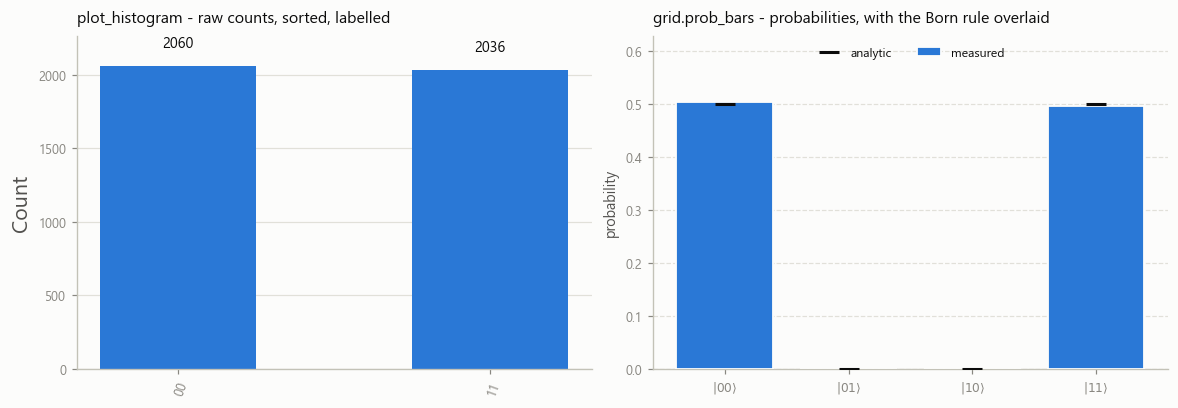

largest deviation from analytic: 0.0029


In [15]:
qr, cr = QuantumRegister(2, "q"), ClassicalRegister(2, "c")
qc_meas = QuantumCircuit(qr, cr)
qc_meas.compose(qc_bell, inplace=True)
qc_meas.measure([0, 1], [0, 1])

SHOTS = 4096
result = StatevectorSampler(seed=SEED).run([qc_meas], shots=SHOTS).result()
counts = result[0].data.c.get_counts()          # ".c" = the register's NAME
print(counts)

analytic = np.abs(sv_bell.data) ** 2
measured = np.array([counts.get(format(i, "02b"), 0) / SHOTS for i in range(4)])

fig, axes = plt.subplots(1, 2, figsize=(10.6, 3.6))
plot_histogram(counts, ax=axes[0], color=style.BLUE, bar_labels=True)
axes[0].set_title("plot_histogram - raw counts, sorted, labelled", loc="left",
                  fontsize=10.5, color=style.INK)
grid.prob_bars(axes[1], measured, analytic=analytic)
axes[1].legend(loc="upper center", ncol=2, fontsize=8)
axes[1].set_title("grid.prob_bars - probabilities, with the Born rule overlaid",
                  loc="left", fontsize=10.5, color=style.INK)
plt.show()

print("largest deviation from analytic:",
      round(float(np.abs(measured - analytic).max()), 4))

## Qiskit's renderings vs this repo's, honestly

This repo draws its own amplitude bars, and it would be dishonest to pretend they
win everywhere. Here is one 3-qubit state — unequal magnitudes, eight different
phases — both ways. (Two figures, not two panels: the qsphere owns its figure.)

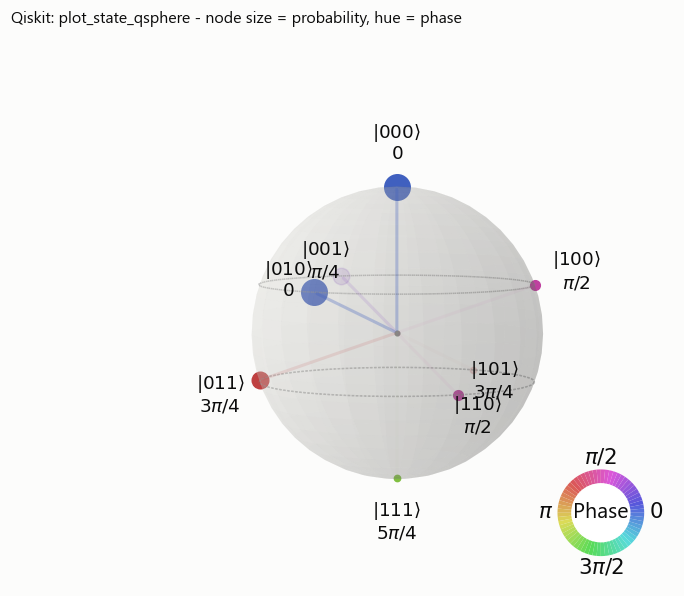

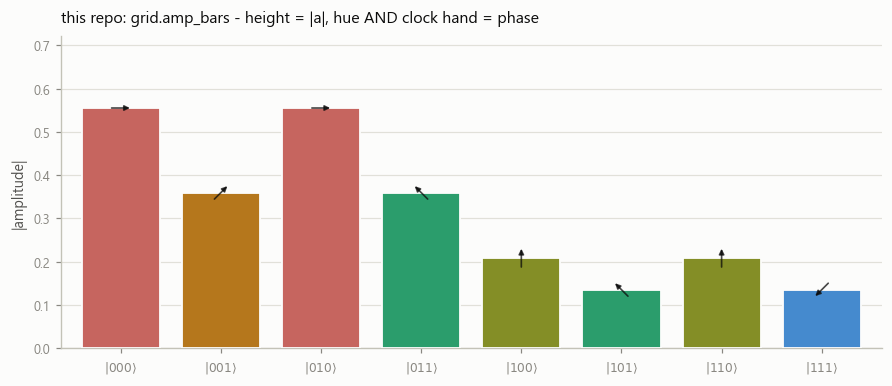

In [16]:
qc3 = QuantumCircuit(3)
qc3.ry(1.15, 0)
qc3.h(1)
qc3.ry(0.72, 2)
qc3.t(0)
qc3.cp(np.pi / 2, 0, 1)
qc3.s(2)
sv3 = Statevector(qc3)

f = plot_state_qsphere(sv3, figsize=(7.0, 5.8), show_state_phases=True)
f.suptitle("Qiskit: plot_state_qsphere - node size = probability, hue = phase",
           x=0.02, y=1.01, ha="left", fontsize=10.5, color=style.INK)
display(f)
plt.close(f)

fig, ax = plt.subplots(figsize=(8.0, 3.4))
grid.amp_bars(ax, sv3.data)
ax.set_title("this repo: grid.amp_bars - height = |a|, hue AND clock hand = phase",
             loc="left", fontsize=10.5, color=style.INK)
plt.show()

**Where Qiskit's is better.**

- The qsphere's **latitude = Hamming weight** layout is a real idea and we have no
  equivalent. On a Grover or Deutsch–Jozsa state it groups the basis states so
  that the answer's structure is visible immediately.
- `plot_state_paulivec` has **no counterpart here at all**, and it is arguably the
  most practically relevant view in the suite, because expectation values are what
  an `EstimatorV2` and real hardware actually return.
- `plot_state_city` and `plot_state_hinton` handle **mixed states** natively.
  `amp_bars` takes a statevector and simply cannot draw a $\rho$ that is not pure
  — A12 and B26 fall back to heatmaps and the Bloch ball.
- `plot_histogram` gets many count dictionaries, legends and top-$k$ truncation
  for free.
- All of them work on anything you hand them with zero setup. Ours need a NumPy
  array in the right convention.

**Where ours is better.**

- **The phase colormap is cyclic *and* constant-lightness.** The qsphere colours
  phase from an `hsv`-family sweep whose lightness swings wildly, so a phase near
  yellow reads as brighter and more important than one near blue. Ours holds OKLCH
  lightness fixed, so no phase is privileged over another.
- **Phase ships with a second, colour-independent channel.** The clock hands keep
  the bars readable in greyscale and under colour-vision deficiency. No cyclic
  colormap can be CVD-safe on its own — CVD collapses the hue circle onto a line,
  so any map that returns to its start must self-intersect. The qsphere has only
  the hue.
- **Magnitude is a length, not an area.** Position and length are the most
  accurately-read visual channels there are; the qsphere encodes probability as
  node *area* on a sphere, which is a weaker channel to begin with and is then
  projected through a perspective transform.
- **Crowding.** Look at the figure above: at eight basis states the qsphere's
  labels already collide ($|001\rangle$ over $|010\rangle$, $|101\rangle$ over
  $|110\rangle$), because the nodes on a latitude ring are placed by Hamming
  weight and there are three states at weight 1. Bars simply get narrower.
- Every figure in this repo shares one palette and one type scale, so thirty
  notebooks read as one document.

The useful summary: **reach for `paulivec` and `qsphere` when you want Qiskit's
semantics, reach for bars when you want to read numbers off the picture, and never
use `plot_bloch_multivector` as evidence that nothing is happening.**

## Honest limits — including this notebook's

- **`plot_bloch_multivector` on an entangled state shows the origin.** The whole
  point above. Treat a short arrow as a flag, not a result.
- **A short arrow does not distinguish entanglement from noise.** A qubit
  entangled with its neighbour and a qubit that has decohered into its environment
  both give $\lVert\vec r\rVert < 1$, and the picture cannot say which. In a real
  sense they are the *same phenomenon* — decoherence is entanglement with
  something you cannot see. A12 and B26 pursue that.
- **Every one of these plots is $O(4^n)$ or worse.** `plot_state_city` on 5 qubits
  is a $32\times32$ field of towers: 1024 bars, unreadable. `plot_state_hinton`
  degrades a little more gracefully; the qsphere is hopeless past about 5 qubits
  (32 nodes on one sphere). No state visualizer in this suite is useful at 10
  qubits, and that is a hard limit rather than a missing feature.
- **They all need the full statevector.** On hardware you never have one, and
  reconstructing it costs $4^n$ measurement settings, which is why full state
  tomography stops being practical around 5 qubits. Every figure in this notebook
  is a simulator privilege.
- **`plot_state_city` should mostly not be used.** It is the most eye-catching
  plot in the suite and the least readable one. It is here because you will meet
  it in every tutorial and should know what to reach for instead.
- **This notebook stayed at 2 and 3 qubits and used no noise.** Everything is an
  ideal simulator; B26 is where that assumption comes apart.

## Checkpoint

Track B closes by asserting against the Track A result it mirrors. This one pairs
with **A02 — The Bloch Sphere**: rebuild the Bloch vector from scratch the A02
way, including the partial trace, and check it against what Qiskit's
`Statevector` / `DensityMatrix` / `partial_trace` produce.

In [17]:
# --- A02's machinery, rebuilt from scratch (nothing from qiskit in this block) ---
def a02_density(state):
    """rho = |psi><psi|. The outer product kills the global phase."""
    v = np.asarray(state, dtype=complex).reshape(-1, 1)
    return v @ v.conj().T


def a02_expect(op, state):
    """<psi|O|psi>. Real whenever O is Hermitian."""
    return float(np.real(np.vdot(state, op @ state)))


def a02_bloch(state):
    """r = (<X>, <Y>, <Z>) -- A02's map, verbatim."""
    return np.array([a02_expect(P, state) for P in PAULIS])


def a02_partial_trace_q0(rho4):
    """Trace out qubit 1 by hand. Little-endian: index = 2*q1 + q0."""
    out = np.zeros((2, 2), dtype=complex)
    for a in range(2):
        for b in range(2):
            for q1 in range(2):
                out[a, b] += rho4[2 * q1 + a, 2 * q1 + b]
    return out


# 1. A02's from-scratch Bloch map == Qiskit's reduced-state Bloch vector.
for q, psi in [(0, psi0), (1, psi1)]:
    r_hand = a02_bloch(psi)                       # from the 2-vector, by hand
    r_qk = bloch_of(reduced(sv_prod, q))          # via Statevector/partial_trace
    assert np.allclose(r_hand, r_qk), (q, r_hand, r_qk)
    assert np.isclose(np.linalg.norm(r_hand), 1.0)   # pure -> on the sphere

# 2. The hand-rolled partial trace agrees with qiskit.quantum_info.partial_trace,
#    on the product state and on the entangled one.
for sv in (sv_prod, sv_bell):
    assert np.allclose(a02_partial_trace_q0(a02_density(sv.data)),
                       partial_trace(sv, [1]).data)

# 3. rho = (I + r . sigma)/2 inverts the map (A02's reconstruction) -- on the
#    Bell state's MIXED reduced qubit as well as on the pure product one.
for sv in (sv_prod, sv_bell):
    for q in (0, 1):
        rho = reduced(sv, q)
        r = bloch_of(rho)
        rebuilt = 0.5 * (np.eye(2) + sum(ri * P for ri, P in zip(r, PAULIS)))
        assert np.allclose(rebuilt, rho)

# 4. THE claim of this notebook: both Bell Bloch vectors are exactly zero and
#    each reduced qubit is exactly I/2 -- so the picture really does show nothing.
for q in (0, 1):
    rho = reduced(sv_bell, q)
    assert np.allclose(bloch_of(rho), np.zeros(3), atol=1e-12)
    assert np.allclose(rho, 0.5 * np.eye(2))
    assert np.isclose(float(np.real(np.trace(rho @ rho))), 0.5)   # purity 1/2
# ...while the PAIR is pure. Nothing was lost; it was never per-qubit.
rho_bell = DensityMatrix(sv_bell).data
assert np.isclose(float(np.real(np.trace(rho_bell @ rho_bell))), 1.0)

# 5. Correlation table: the product state's corner block is the outer product of
#    its two Bloch vectors; the Bell state's edges vanish and its diagonal does not.
assert np.allclose(M_prod[1:, 1:], np.outer(r0_p, r1_p))
assert np.allclose(M_bell[0, 1:], 0) and np.allclose(M_bell[1:, 0], 0)
assert np.allclose(np.diag(M_bell[1:, 1:]), [1.0, -1.0, 1.0])

# 6. The dial is analytic: |r_0(t)| = |cos 2t| for cos t|00> + sin t|11>.
assert np.allclose(r_len, np.abs(np.cos(2 * ts_fine)))
assert np.isclose(ent[np.argmin(r_len)], 1.0, atol=1e-6)   # 1 full bit at |r|=0

# 7. Born rule: sampled frequencies match |amplitude|^2 within shot noise.
assert np.abs(measured - analytic).max() < 5 * np.sqrt(0.25 / SHOTS)

print("B14 checkpoint passed - Qiskit's Bloch vectors are A02's, to 1e-15.")

B14 checkpoint passed - Qiskit's Bloch vectors are A02's, to 1e-15.


---

**Next:** [B15 — Single-Qubit Gates in Qiskit](B15_Single_Qubit_Gates_Qiskit.ipynb),
which puts the contact sheet to work on a twelve-gate comparison.